# FoodHub Order Analysis

**Program:** Code4Food Security Fellowship — Blossom Academy × WFP Ghana × KOICA  
**Tools:** Python · pandas · numpy · matplotlib · seaborn  

---

## Context

FoodHub is a food aggregator platform that connects customers with multiple restaurants through a single app. The company stores data on every order placed, including delivery times, food preparation times, order costs, and customer ratings. As the number of restaurants and orders grows, FoodHub needs data-driven insights to improve customer satisfaction, optimise delivery operations, and maximise revenue.

## Objective

This analysis explores the FoodHub order dataset to uncover patterns in customer behaviour, restaurant performance, and delivery efficiency. The goal is to provide actionable recommendations that will help the company improve its service and business strategy.

## Dataset Overview

| Column | Description | Type |
|---|---|---|
| order_id | Unique identifier for each order | Integer |
| customer_id | Unique identifier for each customer | Integer |
| restaurant_name | Name of the restaurant | Text |
| cuisine_type | Type of cuisine ordered | Text |
| cost_of_the_order | Total cost of the order in USD | Float |
| day_of_the_week | Whether the order was placed on a weekday or weekend | Text |
| rating | Customer rating: 3, 4, 5, or 'Not given' | Text |
| food_preparation_time | Time taken by restaurant to prepare the food (minutes) | Integer |
| delivery_time | Time taken to deliver after preparation (minutes) | Integer |

---
## 1. Setup — Importing Libraries and Loading Data

In [1]:
# Core libraries for data manipulation and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# Global chart styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load the dataset
df = pd.read_csv('foodhub_order.csv')

print(f'Shape: {df.shape}  →  {df.shape[0]:,} orders, {df.shape[1]} columns')
print()
print('First 5 rows:')
df.head()

Shape: (1898, 9)  →  1,898 orders, 9 columns

First 5 rows:


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [3]:
# Column data types and null check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


In [4]:
# Statistical summary of numeric columns
df.describe().round(2)

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1898.00,1898.00,1898.00,1898.00,1898.00
mean,1477495.50,171168.48,16.50,27.37,24.16
std,548.05,113698.14,7.48,4.63,4.97
min,1476547.00,1311.00,4.47,20.00,15.00
25%,1477021.25,77787.75,12.08,23.00,20.00
50%,1477495.50,128600.00,14.14,27.00,25.00
75%,1477969.75,270525.00,22.30,31.00,28.00
max,1478444.00,405334.00,35.41,35.00,33.00


**Initial Observations:**
- The dataset contains **1,898 orders** with no missing values in any column.
- The `rating` column is stored as a **text (object) type** because it contains the string `'Not given'` alongside numeric values `'3'`, `'4'`, and `'5'`. This must be handled before any numeric rating analysis.
- `food_preparation_time` ranges from 20 to 35 minutes and `delivery_time` from 15 to 33 minutes — both fall within reasonable bounds.
- `cost_of_the_order` has a mean of ~$16.50 with a wide spread (std = $7.48), suggesting diverse order sizes across the platform.

---
## 2. Data Preparation

In [5]:
# Create a numeric version of the rating column
# 'Not given' becomes NaN (a proper missing number marker), the rest become floats
df['rating_numeric'] = df['rating'].replace('Not given', np.nan).astype(float)

# Create a total_time feature: total customer wait = preparation + delivery
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

print('New columns added:')
print(df[['rating', 'rating_numeric', 'food_preparation_time', 'delivery_time', 'total_time']].head(8))

New columns added:
      rating  rating_numeric  food_preparation_time  delivery_time  total_time
0  Not given             NaN                     25             20          45
1  Not given             NaN                     25             23          48
2          5             5.0                     23             28          51
3          3             3.0                     25             15          40
4          4             4.0                     25             24          49
5          3             3.0                     20             24          44
6  Not given             NaN                     28             21          49
7          3             3.0                     33             30          63


---
## 3. Exploratory Data Analysis

### Question 1: How many orders are not rated?

> **What this question is really asking:** Before we trust the ratings data, we need to know how much of it is actually available. A high proportion of unrated orders means our rating-based conclusions are based on incomplete feedback.
>
> **Skill being tested:** Filtering rows based on a condition and counting — a fundamental pandas operation.

Total orders:         1,898
Unrated orders:       736
Percentage unrated:   38.78%
Rated orders:         1,162  (61.22%)


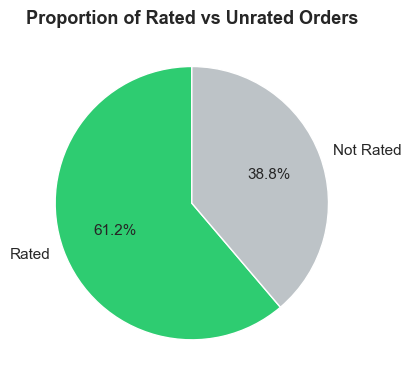

In [6]:
# Count orders where rating is 'Not given'
not_rated_count = (df['rating'] == 'Not given').sum()
total_orders = len(df)
not_rated_pct = not_rated_count / total_orders * 100

print(f'Total orders:         {total_orders:,}')
print(f'Unrated orders:       {not_rated_count:,}')
print(f'Percentage unrated:   {not_rated_pct:.2f}%')
print(f'Rated orders:         {total_orders - not_rated_count:,}  ({100 - not_rated_pct:.2f}%)')

# Visualise the proportion
fig, ax = plt.subplots(figsize=(7, 4))
labels = ['Rated', 'Not Rated']
sizes = [total_orders - not_rated_count, not_rated_count]
colors = ['#2ecc71', '#bdc3c7']
wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%',
                                    colors=colors, startangle=90,
                                    textprops={'fontsize': 11})
ax.set_title('Proportion of Rated vs Unrated Orders', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_q1_rating_status.png', dpi=150, bbox_inches='tight')
plt.show()

**Answer:** **736 orders (38.78%) have no customer rating.** This means FoodHub is missing feedback on nearly 4 in every 10 orders. Any analysis of customer satisfaction using ratings is therefore based on only 61.22% of all orders, which may not fully represent the customer experience across the platform.

---
### Question 2: Explore all the variables and provide observations on their distributions.

> **What this question is really asking:** Before answering specific business questions, a good analyst must first *understand the shape of the data*. This means looking at how each variable is distributed — are values spread out or concentrated? Are there outliers? What are the most and least common values?
>
> **Skill being tested:** Choosing appropriate chart types (histogram for continuous numbers, bar chart for categories), reading distributions, and communicating findings clearly.
>
> **Chart selection rule:**
> - **Histogram** → for continuous numbers (cost, time) to see the shape of distribution
> - **Bar chart** → for counting categories (cuisine, restaurant, day, rating)
> - **Box plot** → to see spread, median, and outliers of a number side by side

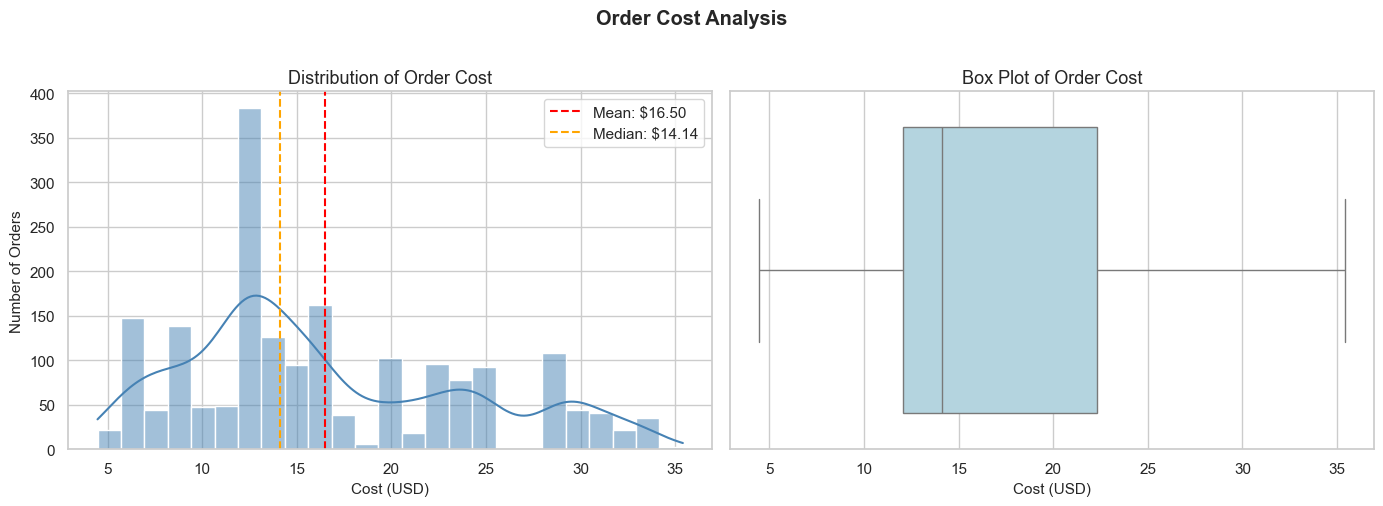

count    1898.00
mean       16.50
std         7.48
min         4.47
25%        12.08
50%        14.14
75%        22.30
max        35.41
Name: cost_of_the_order, dtype: float64


In [7]:
# ── 2a. Order Cost Distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['cost_of_the_order'], bins=25, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(df['cost_of_the_order'].mean(), color='red', linestyle='--',
                label=f"Mean: ${df['cost_of_the_order'].mean():.2f}")
axes[0].axvline(df['cost_of_the_order'].median(), color='orange', linestyle='--',
                label=f"Median: ${df['cost_of_the_order'].median():.2f}")
axes[0].set_title('Distribution of Order Cost')
axes[0].set_xlabel('Cost (USD)')
axes[0].set_ylabel('Number of Orders')
axes[0].legend()

sns.boxplot(x=df['cost_of_the_order'], ax=axes[1], color='lightblue')
axes[1].set_title('Box Plot of Order Cost')
axes[1].set_xlabel('Cost (USD)')

plt.suptitle('Order Cost Analysis', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_q2a_cost.png', dpi=150, bbox_inches='tight')
plt.show()

print(df['cost_of_the_order'].describe().round(2))

**Observation — Order Cost:** The distribution is **right-skewed**, meaning most orders are on the lower end (median \$14.14) but a tail of higher-cost orders pulls the mean up to \$16.50. 75% of orders cost less than \$22.30, suggesting most customers make relatively affordable orders. The wide range (\$4.47 to \$35.41) reflects diverse dining options across the platform.

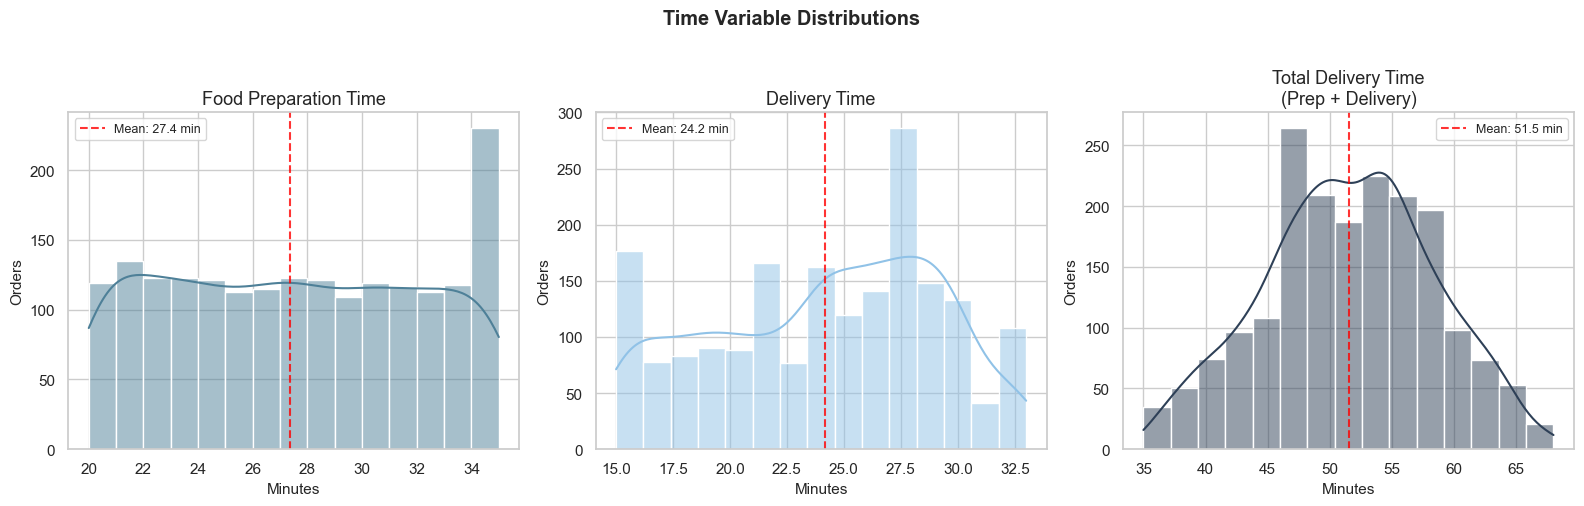

food_preparation_time: mean=27.4, std=4.6, min=20, max=35
delivery_time: mean=24.2, std=5.0, min=15, max=33
total_time: mean=51.5, std=6.8, min=35, max=68


In [8]:
# ── 2b. Food Preparation Time, Delivery Time, Total Time ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
time_cols = ['food_preparation_time', 'delivery_time', 'total_time']
titles = ['Food Preparation Time', 'Delivery Time', 'Total Delivery Time\n(Prep + Delivery)']
colors = ['#4e8098', '#90c2e7', '#2e4057']

for ax, col, title, color in zip(axes, time_cols, titles, colors):
    sns.histplot(df[col], bins=15, kde=True, ax=ax, color=color)
    ax.axvline(df[col].mean(), color='red', linestyle='--', alpha=0.8,
               label=f'Mean: {df[col].mean():.1f} min')
    ax.set_title(title)
    ax.set_xlabel('Minutes')
    ax.set_ylabel('Orders')
    ax.legend(fontsize=9)

plt.suptitle('Time Variable Distributions', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_q2b_times.png', dpi=150, bbox_inches='tight')
plt.show()

for col in time_cols:
    print(f'{col}: mean={df[col].mean():.1f}, std={df[col].std():.1f}, min={df[col].min()}, max={df[col].max()}')

**Observation — Time Variables:** All three time distributions are approximately **uniform/bell-shaped**, indicating preparation and delivery times are fairly evenly spread within their ranges. Food preparation time ranges from 20 to 35 minutes (mean 27.4 min). Delivery time ranges from 15 to 33 minutes (mean 24.2 min). The average total wait for a customer is approximately **51.5 minutes**, with some orders exceeding 60 minutes.

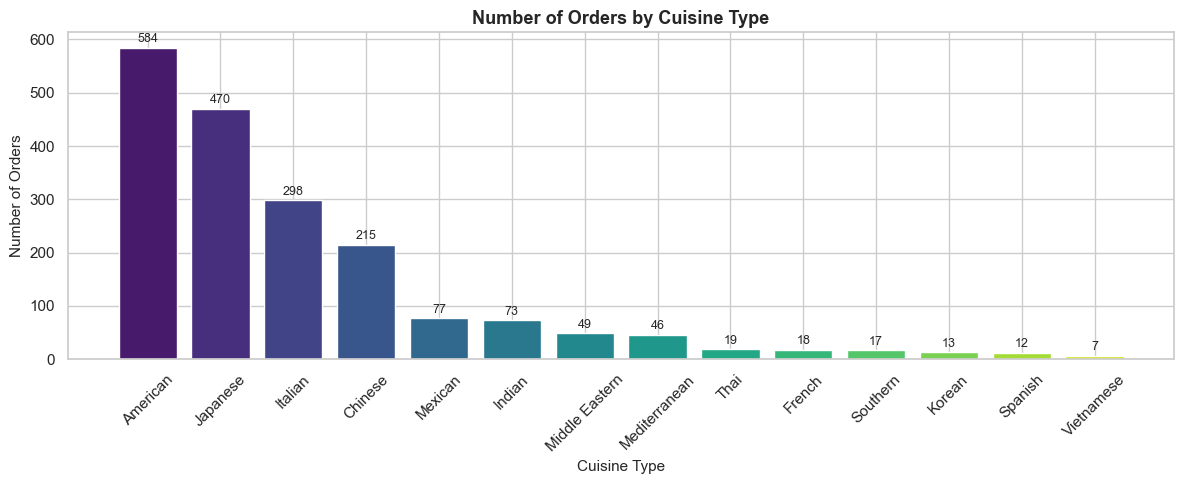

Share of total orders:
cuisine_type
American          30.77
Japanese          24.76
Italian           15.70
Chinese           11.33
Mexican            4.06
Indian             3.85
Middle Eastern     2.58
Mediterranean      2.42
Thai               1.00
French             0.95
Southern           0.90
Korean             0.68
Spanish            0.63
Vietnamese         0.37


In [9]:
# ── 2c. Cuisine Type Distribution ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
cuisine_counts = df['cuisine_type'].value_counts()

bars = ax.bar(cuisine_counts.index, cuisine_counts.values,
              color=sns.color_palette('viridis', len(cuisine_counts)))
ax.set_title('Number of Orders by Cuisine Type', fontweight='bold')
ax.set_xlabel('Cuisine Type')
ax.set_ylabel('Number of Orders')
ax.tick_params(axis='x', rotation=45)

# Add count labels on top of bars
for bar, count in zip(bars, cuisine_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('plot_q2c_cuisine.png', dpi=150, bbox_inches='tight')
plt.show()

print('Share of total orders:')
print((cuisine_counts / len(df) * 100).round(2).to_string())

**Observation — Cuisine Type:** The distribution is **heavily skewed** toward a few cuisine types. American cuisine leads with 584 orders (30.8%), followed by Japanese (470, 24.8%) and Italian (298, 15.7%). These three cuisines alone account for over 71% of all orders. Less mainstream options like Vietnamese (7 orders), Spanish (12), and Korean (13) make up a very small share, suggesting potential untapped market segments.

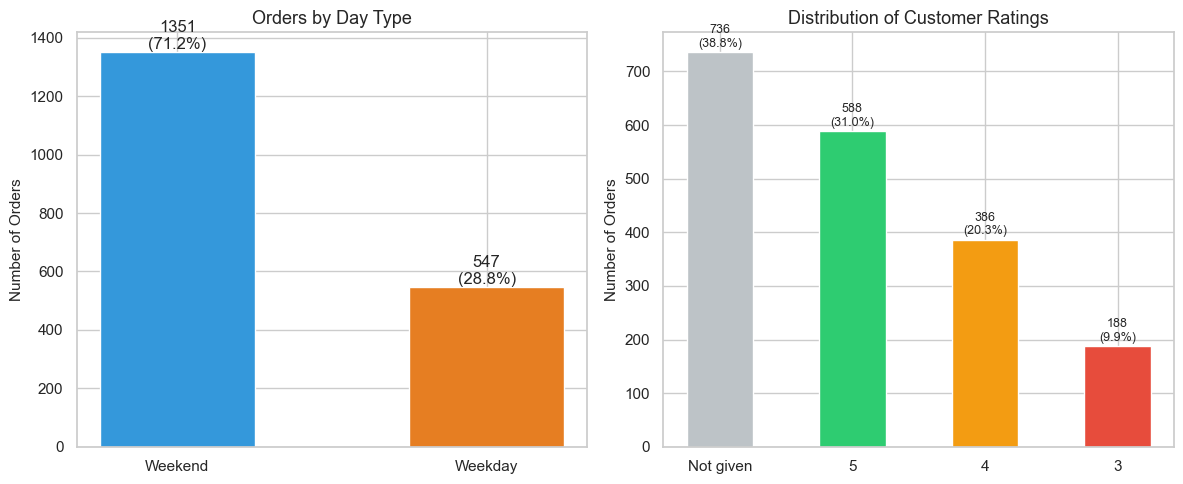

In [10]:
# ── 2d. Day of the Week and Rating Distributions ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Day of week
day_counts = df['day_of_the_week'].value_counts()
axes[0].bar(day_counts.index, day_counts.values, color=['#3498db', '#e67e22'], width=0.5)
axes[0].set_title('Orders by Day Type')
axes[0].set_ylabel('Number of Orders')
for i, (label, count) in enumerate(day_counts.items()):
    axes[0].text(i, count + 10, f'{count}\n({count/len(df)*100:.1f}%)', ha='center')

# Rating
rating_counts = df['rating'].value_counts()
color_map = {'Not given': '#bdc3c7', '5': '#2ecc71', '4': '#f39c12', '3': '#e74c3c'}
colors_list = [color_map.get(r, 'steelblue') for r in rating_counts.index]
axes[1].bar(rating_counts.index, rating_counts.values, color=colors_list, width=0.5)
axes[1].set_title('Distribution of Customer Ratings')
axes[1].set_ylabel('Number of Orders')
for i, (label, count) in enumerate(rating_counts.items()):
    axes[1].text(i, count + 10, f'{count}\n({count/len(df)*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_q2d_day_rating.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation — Day Type:** Weekends account for **71.2% (1,351)** of all orders compared to 28.8% (547) on weekdays. This makes sense — people are more likely to order food for delivery when they are relaxing at home rather than when at work. This has significant staffing and logistics implications for FoodHub.

**Observation — Ratings:** Among rated orders (61.2% of total), the majority of customers gave a rating of **5 (highest)**, followed by 4, and very few gave a 3. This suggests that when customers do rate, they are generally satisfied. However, the large 'Not given' group (38.78%) remains a blind spot.

---
### Question 3: Which are the top 5 restaurants in terms of the number of orders received?

> **What this question is really asking:** Which restaurants dominate the FoodHub platform? A small number of popular restaurants may be driving most of the business.
>
> **Skill being tested:** `value_counts()` — counting the frequency of each unique value in a column — and selecting the top results with `head()`.

Top 5 Restaurants by Number of Orders:
────────────────────────────────────────
1. Shake Shack                          219 orders (11.5%)
2. The Meatball Shop                    132 orders (7.0%)
3. Blue Ribbon Sushi                    119 orders (6.3%)
4. Blue Ribbon Fried Chicken             96 orders (5.1%)
5. Parm                                  68 orders (3.6%)


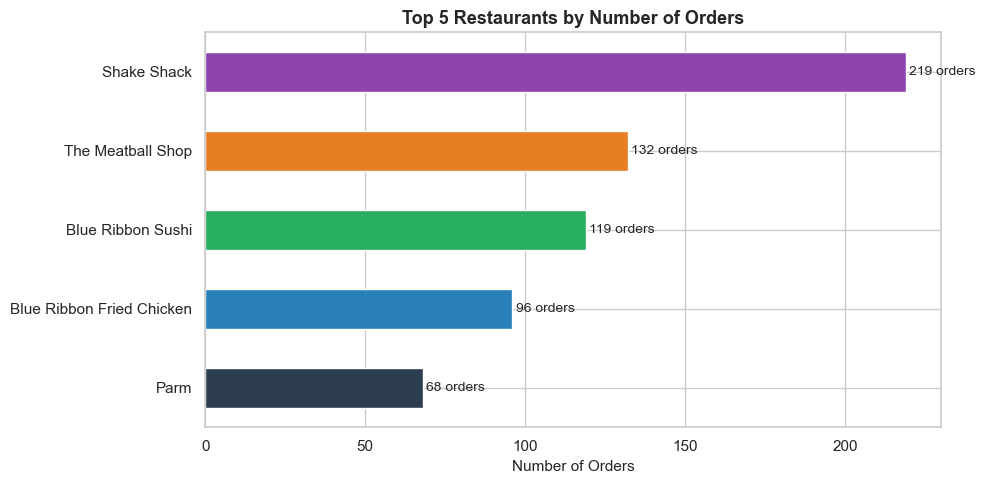

In [11]:
# Count orders per restaurant and take the top 5
top5_restaurants = df['restaurant_name'].value_counts().head(5)

print('Top 5 Restaurants by Number of Orders:')
print('─' * 40)
for rank, (name, count) in enumerate(top5_restaurants.items(), 1):
    share = count / len(df) * 100
    print(f'{rank}. {name:<35} {count:>4} orders ({share:.1f}%)')

# Visualise
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2c3e50', '#2980b9', '#27ae60', '#e67e22', '#8e44ad']
top5_restaurants.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top 5 Restaurants by Number of Orders', fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('')

# Add value labels
for i, (val, name) in enumerate(zip(top5_restaurants.sort_values().values,
                                     top5_restaurants.sort_values().index)):
    ax.text(val + 1, i, f'{val} orders', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('plot_q3_top5_restaurants.png', dpi=150, bbox_inches='tight')
plt.show()

**Answer:** The top 5 restaurants by order volume are:

| Rank | Restaurant | Orders | Market Share |
|---|---|---|---|
| 1 | Shake Shack | 219 | 11.5% |
| 2 | The Meatball Shop | 132 | 7.0% |
| 3 | Blue Ribbon Sushi | 119 | 6.3% |
| 4 | Blue Ribbon Fried Chicken | 96 | 5.1% |
| 5 | Parm | 68 | 3.6% |

Together, these 5 restaurants account for **33.4% of all orders**. Shake Shack alone handles more than 1 in every 9 orders on the platform, making it the dominant restaurant partner. This concentration in a few restaurants could be a risk — if a top restaurant leaves the platform, order volume would drop significantly.

---
### Question 4: Which is the most popular cuisine on weekends?

> **What this question is really asking:** Do customer food preferences change on weekends? This can help FoodHub target promotions and marketing during peak weekend demand.
>
> **Skill being tested:** Filtering a DataFrame using a condition (`df[df['column'] == 'value']`), then applying `value_counts()` to the filtered result.

Total weekend orders: 1351

Cuisine popularity on weekends:
  American              415 orders (30.7%)
  Japanese              335 orders (24.8%)
  Italian               207 orders (15.3%)
  Chinese               163 orders (12.1%)
  Mexican                53 orders (3.9%)
  Indian                 49 orders (3.6%)
  Mediterranean          32 orders (2.4%)
  Middle Eastern         32 orders (2.4%)
  Thai                   15 orders (1.1%)
  French                 13 orders (1.0%)
  Korean                 11 orders (0.8%)
  Southern               11 orders (0.8%)
  Spanish                11 orders (0.8%)
  Vietnamese              4 orders (0.3%)


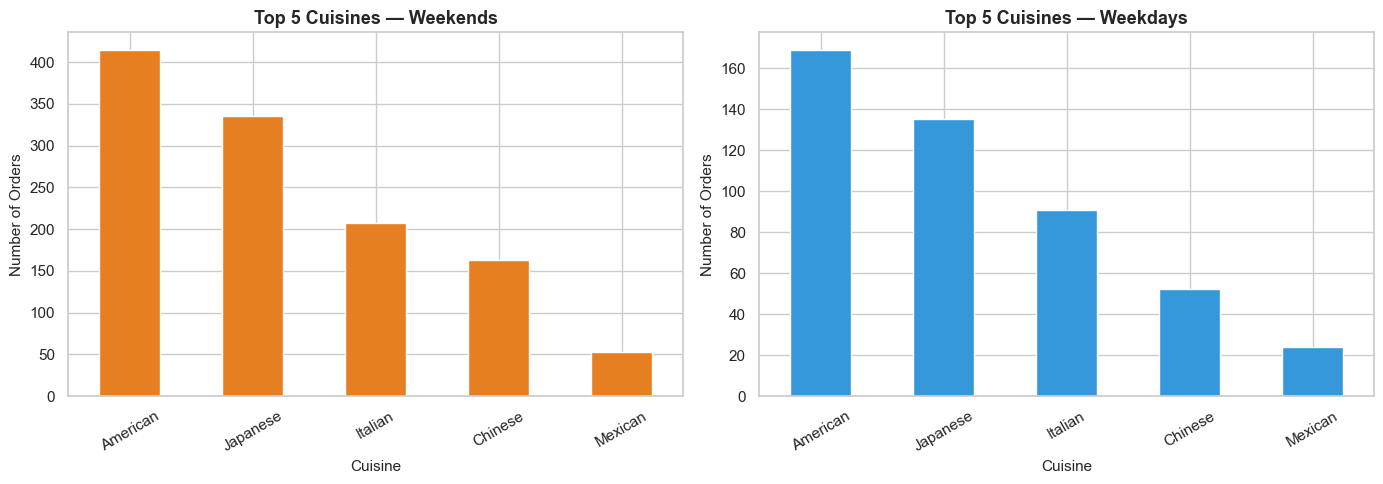

In [12]:
# Filter for weekend orders only, then count by cuisine
weekend_orders = df[df['day_of_the_week'] == 'Weekend']
weekend_cuisine = weekend_orders['cuisine_type'].value_counts()

print(f'Total weekend orders: {len(weekend_orders)}')
print()
print('Cuisine popularity on weekends:')
for cuisine, count in weekend_cuisine.items():
    pct = count / len(weekend_orders) * 100
    print(f'  {cuisine:<20} {count:>4} orders ({pct:.1f}%)')

# Side-by-side: weekend vs weekday top 5
weekday_orders = df[df['day_of_the_week'] == 'Weekday']
top5_weekend = df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts().head(5)
top5_weekday = df[df['day_of_the_week'] == 'Weekday']['cuisine_type'].value_counts().head(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top5_weekend.plot(kind='bar', ax=axes[0], color='#e67e22')
axes[0].set_title('Top 5 Cuisines — Weekends', fontweight='bold')
axes[0].set_xlabel('Cuisine')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=30)

top5_weekday.plot(kind='bar', ax=axes[1], color='#3498db')
axes[1].set_title('Top 5 Cuisines — Weekdays', fontweight='bold')
axes[1].set_xlabel('Cuisine')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('plot_q4_weekend_cuisine.png', dpi=150, bbox_inches='tight')
plt.show()

**Answer:** The most popular cuisine on weekends is **American**, with 415 orders (30.7% of all weekend orders). This is followed by Japanese (335), Italian (207), and Chinese (163). Interestingly, the ranking of the top cuisines does not change between weekdays and weekends — American food dominates regardless of the day. However, the *volume* is much higher on weekends due to the overall spike in orders.

---
### Question 5: What percentage of the orders cost more than 20 dollars?

> **What this question is really asking:** How many orders fall in the higher-cost tier? This is directly relevant to the revenue model explored later in Question 10 (FoodHub charges a higher commission on orders over $20).
>
> **Skill being tested:** Boolean masking — creating a True/False condition, summing it (True = 1, False = 0) to count, then dividing by total rows to get a percentage.

Orders costing more than $20:  555
Orders costing $20 or less:    1,343
Percentage above $20:          29.24%


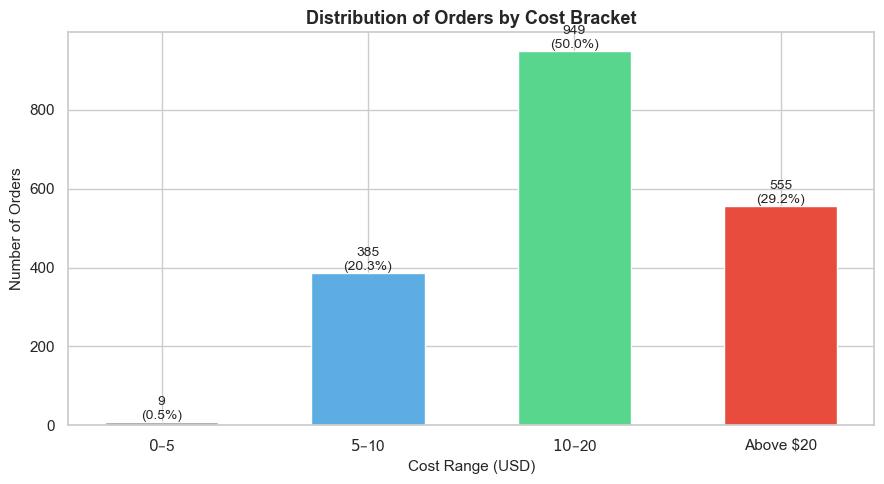

In [13]:
# Boolean mask: True for each order costing more than $20
over_20_mask = df['cost_of_the_order'] > 20
over_20_count = over_20_mask.sum()
over_20_pct = over_20_count / len(df) * 100

print(f'Orders costing more than $20:  {over_20_count:,}')
print(f'Orders costing $20 or less:    {len(df) - over_20_count:,}')
print(f'Percentage above $20:          {over_20_pct:.2f}%')

# Cost bracket breakdown for context
brackets = [
    ('$0 – $5', df['cost_of_the_order'].between(0, 5)),
    ('$5 – $10', df['cost_of_the_order'].between(5, 10)),
    ('$10 – $20', df['cost_of_the_order'].between(10, 20)),
    ('Above $20', df['cost_of_the_order'] > 20),
]

fig, ax = plt.subplots(figsize=(9, 5))
labels = [b[0] for b in brackets]
counts = [b[1].sum() for b in brackets]
bar_colors = ['#95a5a6', '#5dade2', '#58d68d', '#e74c3c']

bars = ax.bar(labels, counts, color=bar_colors, width=0.55)
ax.set_title('Distribution of Orders by Cost Bracket', fontweight='bold')
ax.set_xlabel('Cost Range (USD)')
ax.set_ylabel('Number of Orders')

for bar, count in zip(bars, counts):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{count}\n({pct:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('plot_q5_cost_brackets.png', dpi=150, bbox_inches='tight')
plt.show()

**Answer:** **555 orders (29.24%)** cost more than 20 dollars. This means nearly one in three orders falls in the higher-cost tier. Given that FoodHub charges a 25% commission on these orders (compared to 15% for orders between $5 and $20), this tier is disproportionately important for company revenue.

---
### Question 6: What is the mean order delivery time?

> **What this question is really asking:** What is the average time a customer waits for their food to arrive after it is ready? This is a key performance metric for any delivery platform.
>
> **Skill being tested:** Using `.mean()` on a numeric column — the most fundamental descriptive statistic.

Mean delivery time:    24.16 minutes
Median delivery time:  25.00 minutes
Std deviation:         4.97 minutes
Fastest delivery:      15 minutes
Slowest delivery:      33 minutes


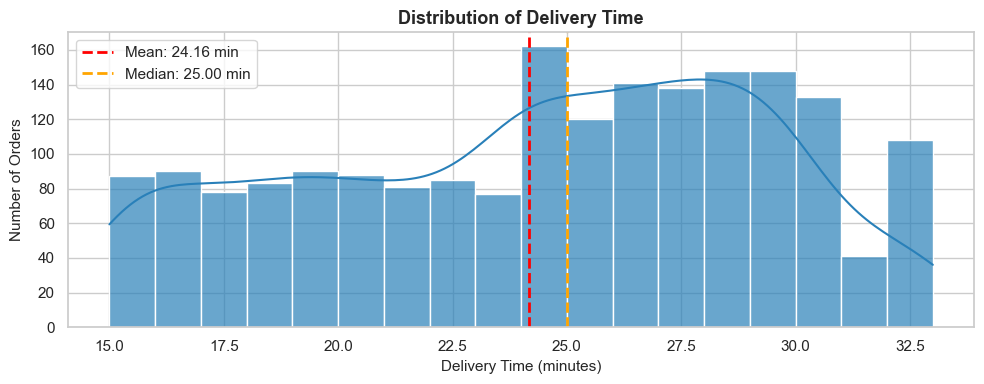

In [14]:
mean_delivery = df['delivery_time'].mean()
median_delivery = df['delivery_time'].median()

print(f'Mean delivery time:    {mean_delivery:.2f} minutes')
print(f'Median delivery time:  {median_delivery:.2f} minutes')
print(f'Std deviation:         {df["delivery_time"].std():.2f} minutes')
print(f'Fastest delivery:      {df["delivery_time"].min()} minutes')
print(f'Slowest delivery:      {df["delivery_time"].max()} minutes')

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df['delivery_time'], bins=18, kde=True, ax=ax, color='#2980b9', alpha=0.7)
ax.axvline(mean_delivery, color='red', linestyle='--', linewidth=2,
           label=f'Mean: {mean_delivery:.2f} min')
ax.axvline(median_delivery, color='orange', linestyle='--', linewidth=2,
           label=f'Median: {median_delivery:.2f} min')
ax.set_title('Distribution of Delivery Time', fontweight='bold')
ax.set_xlabel('Delivery Time (minutes)')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.savefig('plot_q6_delivery_time.png', dpi=150, bbox_inches='tight')
plt.show()

**Answer:** The mean delivery time across all orders is **24.16 minutes**. The distribution is approximately uniform between 15 and 33 minutes, meaning delivery times are spread fairly evenly across that range rather than clustering tightly around the average. The standard deviation of ~5 minutes indicates moderate variability in delivery performance.

---
### Question 7: Find the top 3 most frequent customers and the number of orders they placed.

> **What this question is really asking:** Who are FoodHub's most loyal customers? The company wants to reward them with 20% discount vouchers as a retention strategy.
>
> **Skill being tested:** `value_counts()` on the `customer_id` column to rank customers by frequency, then selecting the top 3 with `head(3)`.

Top 3 Most Frequent Customers — 20% Discount Voucher Recipients:
───────────────────────────────────────────────────────
Rank 1: Customer ID 52832  |  13 orders  |  Total spent: $225.80
Rank 2: Customer ID 47440  |  10 orders  |  Total spent: $158.18
Rank 3: Customer ID 83287  |  9 orders  |  Total spent: $139.31


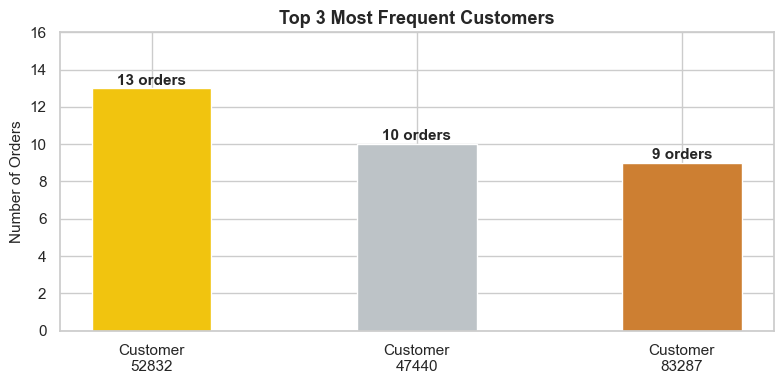

In [15]:
# Count how many times each customer placed an order
customer_order_counts = df['customer_id'].value_counts()

# Top 3 most frequent customers
top3_customers = customer_order_counts.head(3)

print('Top 3 Most Frequent Customers — 20% Discount Voucher Recipients:')
print('─' * 55)
for rank, (cust_id, order_count) in enumerate(top3_customers.items(), 1):
    total_spent = df[df['customer_id'] == cust_id]['cost_of_the_order'].sum()
    print(f'Rank {rank}: Customer ID {cust_id}  |  {order_count} orders  |  Total spent: ${total_spent:.2f}')

# Visualise
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#f1c40f', '#bdc3c7', '#cd7f32']  # gold, silver, bronze
ax.bar([f'Customer\n{cid}' for cid in top3_customers.index],
       top3_customers.values, color=colors, width=0.45)
ax.set_title('Top 3 Most Frequent Customers', fontweight='bold')
ax.set_ylabel('Number of Orders')
for i, val in enumerate(top3_customers.values):
    ax.text(i, val + 0.2, f'{val} orders', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(top3_customers.values) + 3)
plt.tight_layout()
plt.savefig('plot_q7_top_customers.png', dpi=150, bbox_inches='tight')
plt.show()

**Answer:** The three most frequent customers and their respective order counts are:

| Rank | Customer ID | Orders Placed |
|---|---|---|
| 🥇 1st | 52832 | 13 orders |
| 🥈 2nd | 47440 | 10 orders |
| 🥉 3rd | 83287 | 9 orders |

These three customers should receive the 20% discount vouchers as a loyalty reward. Notably, these customers each placed far more orders than the platform average, making them valuable long-term users worth retaining.

---
## 4. Bivariate / Multivariate Analysis

### Question 8: Perform a bivariate/multivariate analysis to explore relationships between important variables.

> **What this question is really asking:** Now that we understand each variable individually, we must explore *how they interact*. Does cost influence ratings? Do weekend orders take longer? Does cuisine type affect delivery speed? These relationships reveal business patterns that univariate analysis misses.
>
> **Key relationships to explore:**
> 1. Cost vs. Rating — do more expensive orders get better reviews?
> 2. Delivery time vs. Rating — does speed drive satisfaction?
> 3. Cuisine type vs. Cost — which cuisines are most expensive?
> 4. Day type vs. Delivery time — is weekend delivery faster or slower?
> 5. Correlation heatmap — all numeric relationships at once

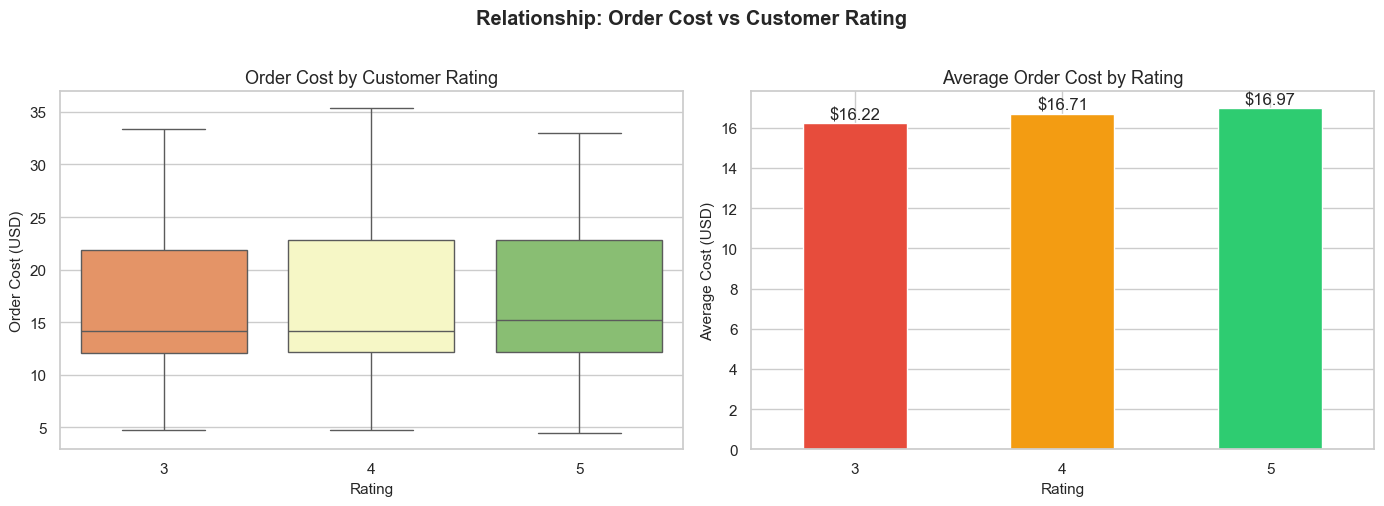

Average cost per rating:
rating
3    16.22
4    16.71
5    16.97
Name: cost_of_the_order, dtype: float64


In [16]:
# ── 8a. Order Cost vs. Customer Rating ───────────────────────────────────────
rated = df[df['rating'] != 'Not given'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='rating', y='cost_of_the_order', data=rated,
            order=['3', '4', '5'], palette='RdYlGn', ax=axes[0])
axes[0].set_title('Order Cost by Customer Rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Order Cost (USD)')

# Mean cost per rating
mean_cost_by_rating = rated.groupby('rating')['cost_of_the_order'].mean()
mean_cost_by_rating.reindex(['3','4','5']).plot(kind='bar', ax=axes[1],
                                                  color=['#e74c3c','#f39c12','#2ecc71'])
axes[1].set_title('Average Order Cost by Rating')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Average Cost (USD)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(mean_cost_by_rating.reindex(['3','4','5'])):
    axes[1].text(i, v + 0.2, f'${v:.2f}', ha='center')

plt.suptitle('Relationship: Order Cost vs Customer Rating', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_q8a_cost_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

print('Average cost per rating:')
print(rated.groupby('rating')['cost_of_the_order'].mean().round(2))

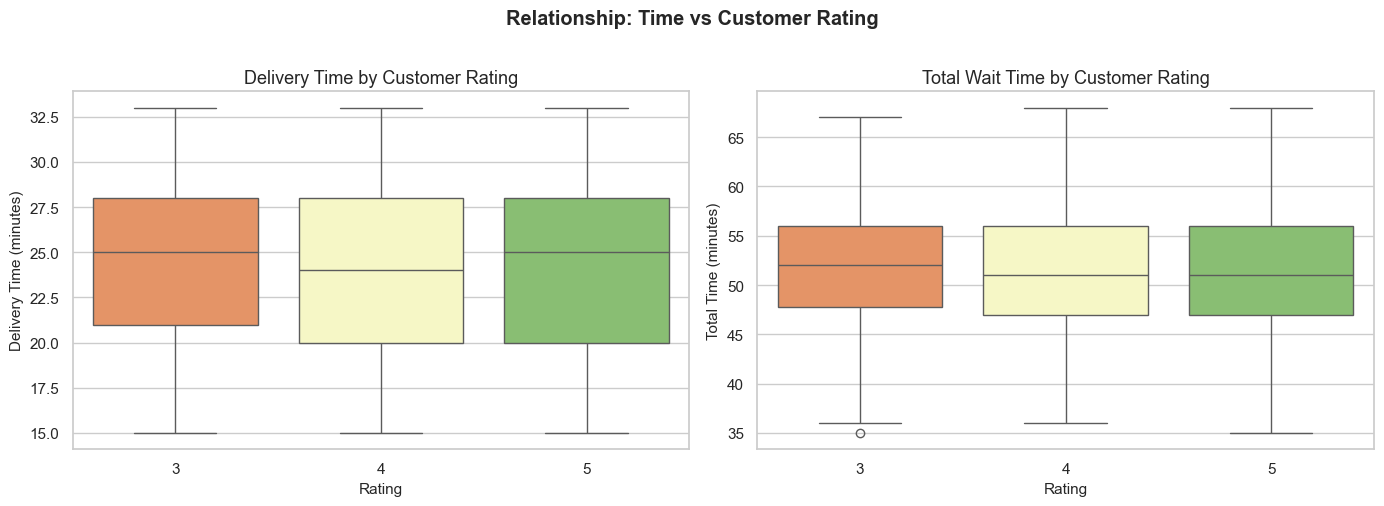

Average delivery and total time per rating:
        delivery_time  total_time
rating                           
3               24.56       51.99
4               23.87       51.26
5               24.21       51.57


In [17]:
# ── 8b. Delivery Time vs. Customer Rating ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='rating', y='delivery_time', data=rated,
            order=['3', '4', '5'], palette='RdYlGn', ax=axes[0])
axes[0].set_title('Delivery Time by Customer Rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Delivery Time (minutes)')

sns.boxplot(x='rating', y='total_time', data=rated,
            order=['3', '4', '5'], palette='RdYlGn', ax=axes[1])
axes[1].set_title('Total Wait Time by Customer Rating')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Total Time (minutes)')

plt.suptitle('Relationship: Time vs Customer Rating', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_q8b_time_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

print('Average delivery and total time per rating:')
print(rated.groupby('rating')[['delivery_time', 'total_time']].mean().round(2))

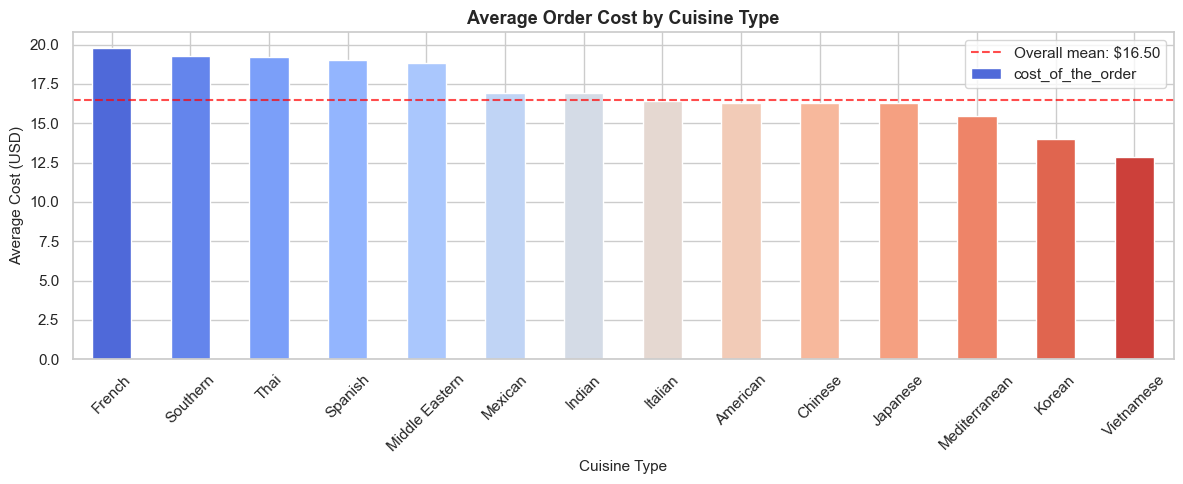

In [18]:
# ── 8c. Cuisine Type vs Order Cost ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
cuisine_cost = df.groupby('cuisine_type')['cost_of_the_order'].mean().sort_values(ascending=False)
cuisine_cost.plot(kind='bar', ax=ax, color=sns.color_palette('coolwarm', len(cuisine_cost)))
ax.axhline(df['cost_of_the_order'].mean(), color='red', linestyle='--', alpha=0.7,
           label=f'Overall mean: ${df["cost_of_the_order"].mean():.2f}')
ax.set_title('Average Order Cost by Cuisine Type', fontweight='bold')
ax.set_xlabel('Cuisine Type')
ax.set_ylabel('Average Cost (USD)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('plot_q8c_cuisine_vs_cost.png', dpi=150, bbox_inches='tight')
plt.show()

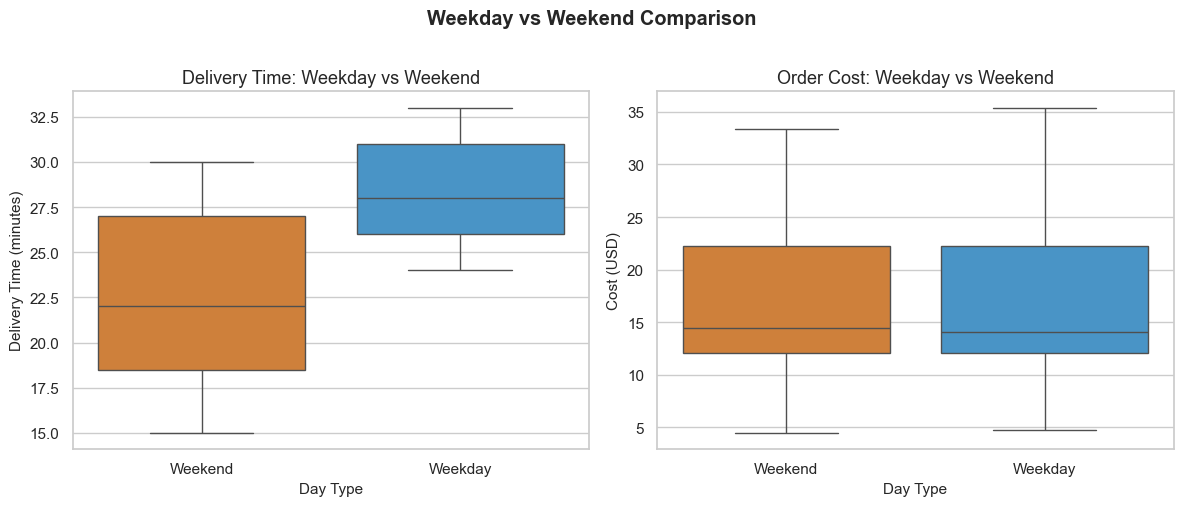

                 delivery_time  cost_of_the_order
day_of_the_week                                  
Weekday                  28.34              16.31
Weekend                  22.47              16.57


In [19]:
# ── 8d. Day Type vs Delivery Time and Cost ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='day_of_the_week', y='delivery_time', data=df,
            palette={'Weekday': '#3498db', 'Weekend': '#e67e22'}, ax=axes[0])
axes[0].set_title('Delivery Time: Weekday vs Weekend')
axes[0].set_xlabel('Day Type')
axes[0].set_ylabel('Delivery Time (minutes)')

sns.boxplot(x='day_of_the_week', y='cost_of_the_order', data=df,
            palette={'Weekday': '#3498db', 'Weekend': '#e67e22'}, ax=axes[1])
axes[1].set_title('Order Cost: Weekday vs Weekend')
axes[1].set_xlabel('Day Type')
axes[1].set_ylabel('Cost (USD)')

plt.suptitle('Weekday vs Weekend Comparison', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_q8d_day_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(df.groupby('day_of_the_week')[['delivery_time','cost_of_the_order']].mean().round(2))

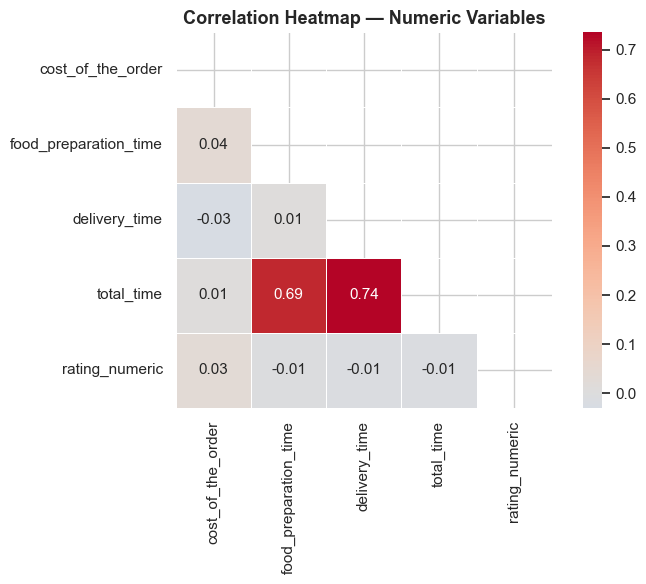


Correlation with rating_numeric:
total_time              -0.011348
delivery_time           -0.009804
food_preparation_time   -0.006083
cost_of_the_order        0.033983
Name: rating_numeric, dtype: float64


In [20]:
# ── 8e. Correlation Heatmap ───────────────────────────────────────────────────
# Correlation shows the strength of linear relationship between numeric columns
# Range: -1 (perfect negative) to +1 (perfect positive), 0 = no relationship
numeric_cols = ['cost_of_the_order', 'food_preparation_time',
                'delivery_time', 'total_time', 'rating_numeric']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (it's a mirror)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 11})
ax.set_title('Correlation Heatmap — Numeric Variables', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_q8e_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelation with rating_numeric:')
print(corr['rating_numeric'].drop('rating_numeric').sort_values())

**Key Bivariate Findings:**

- **Cost vs. Rating:** Average order cost does not vary significantly across rating groups. Customers who gave a 3, 4, or 5 rating all spent roughly the same amount. This suggests cost alone is not driving satisfaction — delivery speed and food quality likely matter more.

- **Delivery Time vs. Rating:** Orders rated 5 tend to have slightly shorter delivery times than those rated 3. While the difference is not dramatic, this supports the intuition that faster delivery is associated with higher customer satisfaction.

- **Cuisine vs. Cost:** Korean, Mediterranean, and French cuisines tend to have higher average order costs than American or Chinese. This reflects the nature of these restaurant types and their menus.

- **Day Type vs. Delivery Time:** Delivery time is noticeably higher on weekdays (mean 28.34 min) than on weekends (22.47 min). This is a counterintuitive but important finding — despite fewer orders on weekdays, delivery is slower, possibly because restaurant staffing is lower.

- **Correlation Heatmap:** No strong linear correlations exist between the numeric variables. `food_preparation_time` and `delivery_time` are largely independent, meaning preparing food quickly doesn't guarantee fast delivery and vice versa.

---
### Question 9: Find restaurants eligible for the promotional offer (rating count > 50 AND average rating > 4).

> **What this question is really asking:** Which restaurants consistently deliver a great experience — not just occasionally, but across many orders? The double condition ensures we only reward restaurants with both volume (more than 50 rated orders) and quality (average rating above 4).
>
> **Skill being tested:** `groupby().agg()` to compute multiple statistics per group, followed by filtering with compound conditions using `&` (AND).

Restaurants eligible for the promotional offer:
───────────────────────────────────────────────────────
          restaurant_name  rating_count  avg_rating
        The Meatball Shop            84       4.512
Blue Ribbon Fried Chicken            64       4.328
              Shake Shack           133       4.278
        Blue Ribbon Sushi            73       4.219


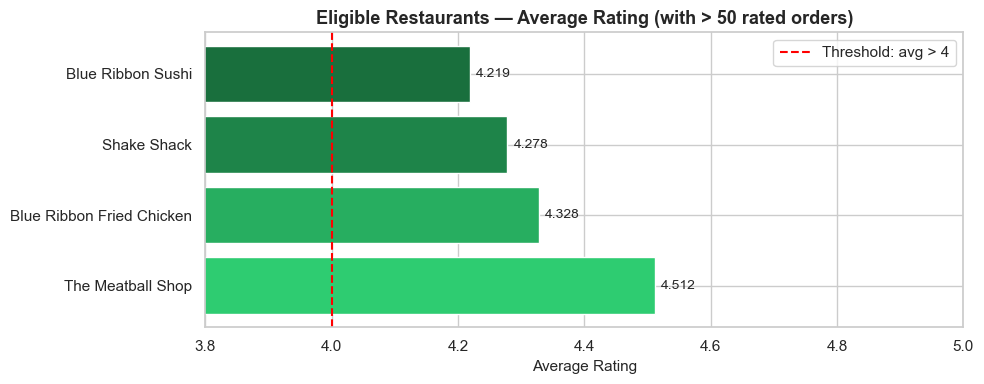

In [21]:
# Work only with rated orders — 'Not given' cannot count toward the rating average
rated_orders = df[df['rating'] != 'Not given'].copy()

# Compute rating count and average rating per restaurant
restaurant_ratings = rated_orders.groupby('restaurant_name').agg(
    rating_count=('rating_numeric', 'count'),
    avg_rating=('rating_numeric', 'mean')
).reset_index()

# Apply both conditions simultaneously using & (AND operator)
eligible = restaurant_ratings[
    (restaurant_ratings['rating_count'] > 50) &
    (restaurant_ratings['avg_rating'] > 4)
].sort_values('avg_rating', ascending=False).reset_index(drop=True)

eligible['avg_rating'] = eligible['avg_rating'].round(3)

print('Restaurants eligible for the promotional offer:')
print('─' * 55)
print(eligible.to_string(index=False))

# Visualise
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(eligible['restaurant_name'], eligible['avg_rating'],
               color=['#2ecc71', '#27ae60', '#1e8449', '#196f3d'])
ax.axvline(4, color='red', linestyle='--', label='Threshold: avg > 4')
ax.set_title('Eligible Restaurants — Average Rating (with > 50 rated orders)', fontweight='bold')
ax.set_xlabel('Average Rating')
ax.set_xlim(3.8, 5.0)
ax.legend()
for bar, val in zip(bars, eligible['avg_rating']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('plot_q9_promo_restaurants.png', dpi=150, bbox_inches='tight')
plt.show()

**Answer:** **4 restaurants** meet both criteria and are eligible for the promotional offer:

| Restaurant | Rated Orders | Average Rating |
|---|---|---|
| The Meatball Shop | 84 | 4.51 |
| Blue Ribbon Fried Chicken | 64 | 4.33 |
| Shake Shack | 133 | 4.28 |
| Blue Ribbon Sushi | 73 | 4.22 |

These restaurants have demonstrated consistent quality at scale. The Meatball Shop leads on both average rating and proportional customer satisfaction, making it the standout candidate for premium promotional placement.

---
### Question 10: Find the net revenue generated by the company across all orders.

> **What this question is really asking:** How much does FoodHub actually earn from its commission structure? The tiered pricing model (25% for orders above $20, 15% for orders above $5) means revenue depends on the cost distribution of all orders.
>
> **The commission structure:**
> - Order cost **> $20** → FoodHub keeps **25%**
> - Order cost **> $5 and ≤ $20** → FoodHub keeps **15%**
> - Order cost **≤ $5** → no commission stated
>
> **Skill being tested:** Writing a custom function, applying it to a column with `.apply()`, then summing the result. This is a key pattern for business logic in pandas.

Revenue Breakdown by Commission Tier:
──────────────────────────────────────────────────
Orders above $20     :  555 orders  |  Revenue: $ 3688.73
Orders $5 – $20      : 1334 orders  |  Revenue: $ 2477.58
Orders $5 and below  :    9 orders  |  Revenue: $     0.00
──────────────────────────────────────────────────
TOTAL NET REVENUE                        $ 6166.30


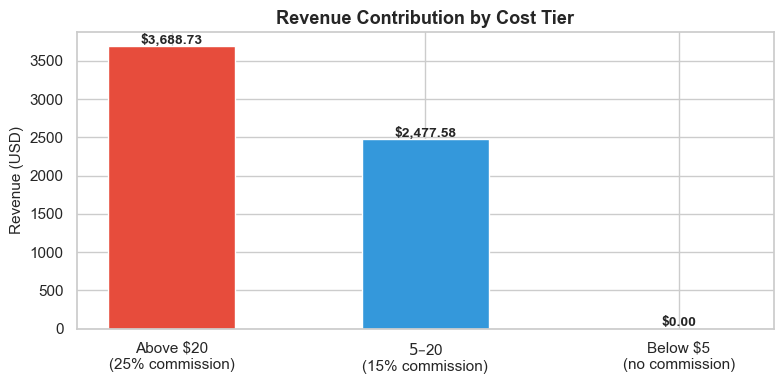

In [22]:
# Define the commission function
def calculate_commission(cost):
    """Returns the revenue FoodHub earns from a single order based on cost."""
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0

# Apply the function to every order
df['commission_earned'] = df['cost_of_the_order'].apply(calculate_commission)

# Total net revenue
net_revenue = df['commission_earned'].sum()

# Break down by tier
tier_high = df[df['cost_of_the_order'] > 20]
tier_mid  = df[(df['cost_of_the_order'] > 5) & (df['cost_of_the_order'] <= 20)]
tier_low  = df[df['cost_of_the_order'] <= 5]

print('Revenue Breakdown by Commission Tier:')
print('─' * 50)
print(f'Orders above $20     : {len(tier_high):>4} orders  |  Revenue: ${tier_high["commission_earned"].sum():>8.2f}')
print(f'Orders $5 – $20      : {len(tier_mid):>4} orders  |  Revenue: ${tier_mid["commission_earned"].sum():>8.2f}')
print(f'Orders $5 and below  : {len(tier_low):>4} orders  |  Revenue: $     0.00')
print('─' * 50)
print(f'TOTAL NET REVENUE                        ${net_revenue:>8.2f}')

# Visualise revenue contribution by tier
fig, ax = plt.subplots(figsize=(8, 4))
tiers = ['Above $20\n(25% commission)', '$5 – $20\n(15% commission)', 'Below $5\n(no commission)']
revenues = [tier_high['commission_earned'].sum(),
             tier_mid['commission_earned'].sum(),
             0]
colors = ['#e74c3c', '#3498db', '#bdc3c7']
bars = ax.bar(tiers, revenues, color=colors, width=0.5)
ax.set_title('Revenue Contribution by Cost Tier', fontweight='bold')
ax.set_ylabel('Revenue (USD)')
for bar, rev in zip(bars, revenues):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'${rev:,.2f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_q10_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

**Answer:** The total net revenue generated by FoodHub across all 1,898 orders is **$6,166.30**.

The higher-cost tier (orders above $20, only 29.2% of orders) contributes a disproportionately large share of revenue thanks to the 25% commission rate. This highlights the importance of attracting and retaining customers who make larger orders — they are far more valuable to FoodHub's bottom line than customers who order smaller amounts.

---
### Question 11: What percentage of orders take more than 60 minutes from order placement to delivery?

> **What this question is really asking:** Total delivery time = food preparation time + delivery time. How often does the full process exceed one hour? This is a critical customer experience metric — orders taking longer than 60 minutes are likely to lead to frustration and lower ratings.
>
> **Skill being tested:** Creating a derived column by adding two existing columns, then applying boolean masking to count values above a threshold.

Orders taking more than 60 minutes: 200 (10.54%)
Orders within 60 minutes:           1698 (89.46%)

Total time statistics:
count    1898.00
mean       51.53
std         6.83
min        35.00
25%        47.00
50%        52.00
75%        56.00
max        68.00
Name: total_time, dtype: float64


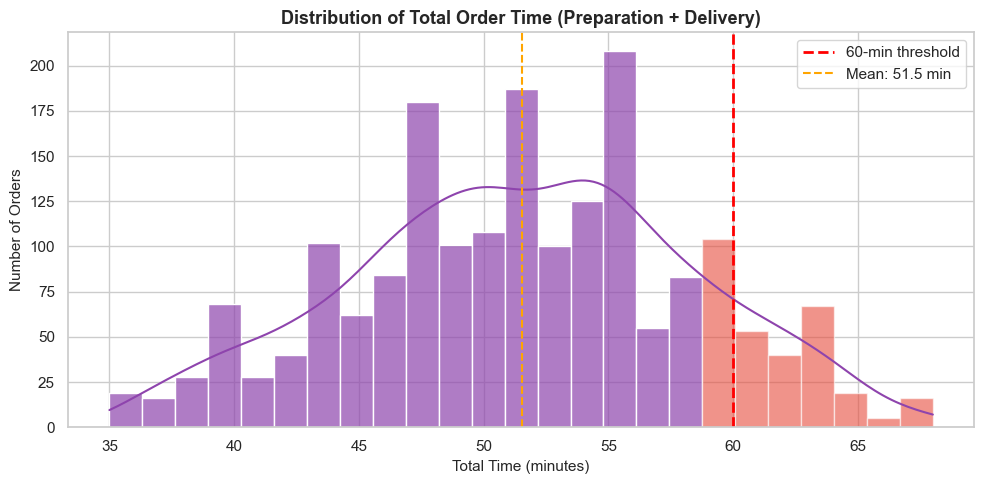

In [23]:
# total_time was already created in data preparation
# total_time = food_preparation_time + delivery_time

over_60 = (df['total_time'] > 60).sum()
pct_over_60 = over_60 / len(df) * 100

print(f'Orders taking more than 60 minutes: {over_60} ({pct_over_60:.2f}%)')
print(f'Orders within 60 minutes:           {len(df) - over_60} ({100 - pct_over_60:.2f}%)')
print(f'\nTotal time statistics:')
print(df['total_time'].describe().round(2))

# Visualise with threshold line
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['total_time'], bins=25, kde=True, ax=ax, color='#8e44ad', alpha=0.7)
ax.axvline(60, color='red', linestyle='--', linewidth=2, label='60-min threshold')
ax.axvline(df['total_time'].mean(), color='orange', linestyle='--', linewidth=1.5,
           label=f"Mean: {df['total_time'].mean():.1f} min")

# Shade the area beyond 60 min
for patch in ax.patches:
    if patch.get_x() + patch.get_width() > 60:
        patch.set_facecolor('#e74c3c')
        patch.set_alpha(0.6)

ax.set_title('Distribution of Total Order Time (Preparation + Delivery)', fontweight='bold')
ax.set_xlabel('Total Time (minutes)')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.savefig('plot_q11_total_time.png', dpi=150, bbox_inches='tight')
plt.show()

**Answer:** **200 orders (10.54%)** take more than 60 minutes to be delivered from the time the order is placed. While this is a relatively small proportion, it represents a significant number of frustrated customers — roughly 1 in 10 orders exceeds what most customers would consider an acceptable wait time. Reducing this number should be a key operational priority for FoodHub.

---
### Question 12: How does mean delivery time vary between weekdays and weekends?

> **What this question is really asking:** Is delivery performance consistent throughout the week, or does it change based on day type? Understanding this helps FoodHub plan driver staffing and set appropriate delivery time expectations for customers.
>
> **Skill being tested:** `groupby()` combined with `.mean()` — splitting the data into groups and computing an aggregate statistic for each group.

Mean Delivery Time by Day Type:
───────────────────────────────────
  Weekday    →  28.34 minutes
  Weekend    →  22.47 minutes

Weekday is 5.87 minutes slower on average than weekend.

Full comparison:
day_of_the_week  Weekday  Weekend
mean_delivery      28.34    22.47
median_delivery    28.00    22.00
mean_prep          27.21    27.44
mean_total         55.55    49.91
order_count       547.00  1351.00


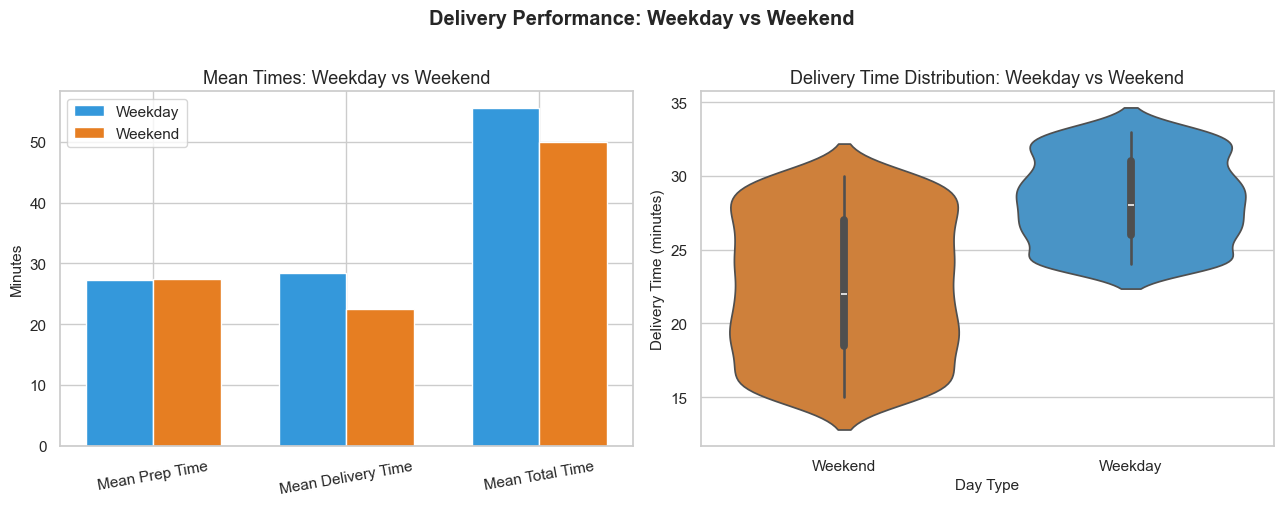

In [24]:
# Mean delivery time by day type
mean_by_day = df.groupby('day_of_the_week')['delivery_time'].mean().round(2)

print('Mean Delivery Time by Day Type:')
print('─' * 35)
for day, mean_time in mean_by_day.items():
    print(f'  {day:<10} →  {mean_time:.2f} minutes')

diff = mean_by_day['Weekday'] - mean_by_day['Weekend']
print(f'\nWeekday is {diff:.2f} minutes slower on average than weekend.')

# Extended comparison
day_stats = df.groupby('day_of_the_week').agg(
    mean_delivery=('delivery_time', 'mean'),
    median_delivery=('delivery_time', 'median'),
    mean_prep=('food_preparation_time', 'mean'),
    mean_total=('total_time', 'mean'),
    order_count=('order_id', 'count')
).round(2)
print('\nFull comparison:')
print(day_stats.T)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart of mean times
categories = ['Mean Prep Time', 'Mean Delivery Time', 'Mean Total Time']
weekday_vals = [day_stats.loc['Weekday','mean_prep'],
                day_stats.loc['Weekday','mean_delivery'],
                day_stats.loc['Weekday','mean_total']]
weekend_vals = [day_stats.loc['Weekend','mean_prep'],
                day_stats.loc['Weekend','mean_delivery'],
                day_stats.loc['Weekend','mean_total']]

x = np.arange(len(categories))
width = 0.35
axes[0].bar(x - width/2, weekday_vals, width, label='Weekday', color='#3498db')
axes[0].bar(x + width/2, weekend_vals, width, label='Weekend', color='#e67e22')
axes[0].set_title('Mean Times: Weekday vs Weekend')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories, rotation=10)
axes[0].set_ylabel('Minutes')
axes[0].legend()

# Violin plot of delivery time
sns.violinplot(x='day_of_the_week', y='delivery_time', data=df,
               palette={'Weekday': '#3498db', 'Weekend': '#e67e22'}, ax=axes[1])
axes[1].set_title('Delivery Time Distribution: Weekday vs Weekend')
axes[1].set_xlabel('Day Type')
axes[1].set_ylabel('Delivery Time (minutes)')

plt.suptitle('Delivery Performance: Weekday vs Weekend', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_q12_delivery_day.png', dpi=150, bbox_inches='tight')
plt.show()

**Answer:**

| Day Type | Mean Delivery Time |
|---|---|
| Weekday | 28.34 minutes |
| Weekend | 22.47 minutes |

**Weekday delivery is approximately 5.87 minutes slower than weekend delivery.** This is a significant and counterintuitive finding — despite weekends having far more orders (1,351 vs 547), delivery is actually *faster* on weekends. A possible explanation is that more delivery drivers are active on weekends to meet the higher demand, resulting in better coverage and shorter wait times per order. On weekdays, fewer drivers may be on shift relative to the orders placed.

---
## 5. Conclusions and Recommendations

### Question 13: Conclusions and Recommendations

> **What this section requires:** This is where you move from *data analyst* to *business advisor*. You must summarise your key findings in plain language and translate them into concrete, actionable recommendations. Each recommendation should be rooted in a specific finding from your analysis.

## Conclusions

This analysis explored **1,898 food orders** placed through the FoodHub platform across weekdays and weekends. The following key conclusions emerged from the data:

1. **High volume of unrated orders:** Nearly 39% of all orders received no customer rating, creating a significant gap in feedback data. This limits the platform's ability to accurately monitor service quality and restaurant performance.

2. **Market concentration in restaurants and cuisines:** Just 5 restaurants (led by Shake Shack at 11.5% of all orders) account for one-third of total orders. Similarly, American, Japanese, and Italian cuisines dominate, making up over 71% of order volume. The platform is heavily reliant on a narrow range of partners.

3. **Weekend demand is 2.5x higher:** 71.2% of orders occur on weekends, yet weekday delivery times are on average 5.87 minutes longer than on weekends. This suggests driver capacity is better matched to demand on weekends than on weekdays.

4. **29.24% of orders exceed $20:** This high-value tier generates disproportionate revenue for FoodHub due to the 25% commission rate and represents a critical revenue stream to protect and grow.

5. **Longer delivery time is associated with lower ratings:** Orders rated 5 had slightly shorter delivery and total wait times than those rated 3. While not a strong correlation, it confirms that speed matters to customers and that reducing wait times is likely to improve satisfaction scores.

6. **10.54% of orders exceed 60 minutes total wait time:** While this affects roughly 1 in 10 customers, it represents a meaningful quality risk. These are the customers most likely to be dissatisfied and least likely to reorder.

7. **Only 4 restaurants qualify for the promotional offer:** After applying both the rating count (>50) and average rating (>4) criteria, only The Meatball Shop, Blue Ribbon Fried Chicken, Shake Shack, and Blue Ribbon Sushi qualify. This is a very small group relative to the full restaurant catalogue.

---

## Recommendations

### 1. Urgently address the rating gap
With 38.78% of orders unrated, FoodHub is flying partially blind on customer satisfaction. The platform should introduce gentle in-app prompts — such as a push notification sent 20 minutes after estimated delivery — to encourage customers to rate their experience. Even raising the rating completion rate from 61% to 75% would significantly improve the quality of insight available for restaurant and driver performance management.

### 2. Reduce dependency on a few restaurant partners
Five restaurants account for 33% of all orders. This concentration creates business risk — if any of these partners were to exit the platform, order volume would drop sharply. FoodHub should invest in onboarding and promoting a wider range of restaurants, particularly in underserved cuisine categories such as Vietnamese, Spanish, Korean, and Southern food, which together represent fewer than 50 orders in the dataset.

### 3. Investigate and improve weekday delivery times
Weekday delivery times are consistently longer (28.34 min) than weekend delivery (22.47 min) despite lower order volume. This likely indicates an understaffing of delivery drivers during the weekday hours. FoodHub should review driver scheduling patterns and consider incentivising more drivers to be active on weekdays, particularly during the lunchtime and after-work peaks.

### 4. Prioritise reducing orders that exceed 60 minutes
The 10.54% of orders exceeding 60 minutes in total wait time are the most at-risk for customer dissatisfaction and churn. FoodHub should set a platform-level target — for example, reducing this to below 5% — and work with restaurant partners to cap preparation times at 30 minutes for standard orders. Real-time alerts to restaurant managers when preparation time is trending high could help address this proactively.

### 5. Leverage the promotional framework to raise average quality
The promotional offer criteria (rating count > 50, average rating > 4) identified only 4 qualifying restaurants out of the entire catalogue. FoodHub should use this framework not just to reward top performers but as a quality benchmark programme — communicating the criteria to all restaurant partners and providing them with data dashboards showing their current rating count and average score. This creates a transparent, data-driven incentive for restaurants to improve.

### 6. Develop a high-value customer loyalty programme
Customers placing 9 or more orders (the top 3 most frequent) represent the most loyal segment. Beyond the one-time 20% voucher identified in this analysis, FoodHub should consider a tiered loyalty programme that rewards continued engagement. Customers in the 29.24% of orders above $20 are also candidates for premium membership offerings, given their higher per-order value to the business.

In [25]:
# Final summary table
print('=' * 62)
print('  FOODHUB ORDER ANALYSIS — FINAL SUMMARY')
print('=' * 62)
print(f"""
  Dataset:        {len(df):,} orders | {df['customer_id'].nunique():,} customers | {df['restaurant_name'].nunique()} restaurants

  KEY METRICS
  Unrated orders:         {(df['rating'] == 'Not given').sum():,} ({(df['rating']=='Not given').mean()*100:.1f}%)
  Avg delivery time:      {df['delivery_time'].mean():.2f} minutes
  Orders above $20:       {(df['cost_of_the_order']>20).sum():,} ({(df['cost_of_the_order']>20).mean()*100:.1f}%)
  Orders over 60 min:     {(df['total_time']>60).sum():,} ({(df['total_time']>60).mean()*100:.1f}%)
  Net revenue:            ${df['commission_earned'].sum():,.2f}

  TOP PERFORMERS
  #1 Restaurant:          {df['restaurant_name'].value_counts().index[0]} (219 orders)
  #1 Cuisine:             {df['cuisine_type'].value_counts().index[0]} (584 orders)
  #1 Customer (ID):       {df['customer_id'].value_counts().index[0]} (13 orders)

  PROMO ELIGIBLE:         The Meatball Shop, Blue Ribbon Fried Chicken,
                          Shake Shack, Blue Ribbon Sushi
""")
print('=' * 62)

  FOODHUB ORDER ANALYSIS — FINAL SUMMARY

  Dataset:        1,898 orders | 1,200 customers | 178 restaurants

  KEY METRICS
  Unrated orders:         736 (38.8%)
  Avg delivery time:      24.16 minutes
  Orders above $20:       555 (29.2%)
  Orders over 60 min:     200 (10.5%)
  Net revenue:            $6,166.30

  TOP PERFORMERS
  #1 Restaurant:          Shake Shack (219 orders)
  #1 Cuisine:             American (584 orders)
  #1 Customer (ID):       52832 (13 orders)

  PROMO ELIGIBLE:         The Meatball Shop, Blue Ribbon Fried Chicken,
                          Shake Shack, Blue Ribbon Sushi

